<a href="https://colab.research.google.com/github/dewith/reinforcement/blob/main/contextual_bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Contextual Bandits

Maybe aggressive pushing works well when you're energetic:

- energy = high
- aggressive → great

but horribly when you're exhausted:

- energy = low
- aggressive → bad

Now asking "What is the best action?" is the wrong question.
We need: "What is the best action given the current context?"

That's a contextual bandit. Formally:

```plain_text
context x
   ↓
choose action a
   ↓
receive reward r
```

The policy becomes: `π(action | context)`.

### Back to the habit tracker exmaple

Assume there's only one contextual variable: `energy ∈ {low, high}`

And the real world behaves like:

```plain_text
                 gentle    aggressive    nothing

low energy        60%         20%          30%
high energy       40%         80%          20%

```


In [1]:
import random

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def get_context(contexts: list[str]) -> str:
    return random.choice(contexts)


def environment(reward_probs: dict[str, list[float]], context: str, action: int) -> int:
    """Returns reward 1 or 0."""
    probability = reward_probs[context][action]
    return 1 if random.random() < probability else 0


def choose_action(
    n_actions: int, values: dict[str, list[float]], context: str, epsilon: float = 0.1
) -> tuple[str, int]:
    """Returns an action given the current context."""
    # Explore
    if random.random() < epsilon:
        return "Explore", random.randrange(n_actions)

    # Exploit
    return "Exploit", max(range(n_actions), key=lambda a: values[context][a])


def update(
    counts: dict[str, list[int]],
    values: dict[str, list[float]],
    context: str,
    action: int,
    reward: int,
) -> None:
    """Updates counts and values."""
    counts[context][action] += 1
    n = counts[context][action]

    # Incremental average
    values[context][action] += (reward - values[context][action]) / n


def pprint(values_by_context: dict[str, list[float]], action_names: list[str]) -> str:
    """Format contextual estimates as one compact row per context."""
    rows = [
        f"  {context:>4}: "
        + ", ".join(
            f"{action_name}={value:.2f}"
            for action_name, value in zip(action_names, values, strict=True)
        )
        for context, values in values_by_context.items()
    ]
    return "\n" + "\n".join(rows)


def plot_progress(
    history: list[dict[str, list[float]]],
    true_probabilities: dict[str, list[float]],
    action_names: list[str],
) -> None:
    """Plot each context's estimated action rewards over time."""
    contexts = list(true_probabilities)
    n_actions = len(action_names)
    steps = range(1, len(history) + 1)
    palette = sns.color_palette("deep", n_actions)
    fig, axes = plt.subplots(
        1,
        len(contexts),
        figsize=(5 * len(contexts), 4),
        dpi=200,
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes[0]

    for ax, context in zip(axes, contexts):
        for action, (true_probability, color) in enumerate(
            zip(true_probabilities[context], palette)
        ):
            estimates = [snapshot[context][action] for snapshot in history]
            sns.lineplot(x=steps, y=estimates, color=color, label=action_names[action], ax=ax)
            ax.axhline(true_probability, color=color, linestyle="--", alpha=0.45)

        ax.set(title=f"{context.title()} energy", xlabel="Iteration", ylim=(0, 1))
        ax.legend().remove()

    axes[0].set_ylabel("Estimated reward")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle(f"Contextual reward estimates after {len(history):,} iterations")
    fig.legend(handles, labels, loc="lower center", ncol=n_actions, frameon=False, title=None)
    sns.despine()
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    plt.show()
    plt.close(fig)

Counts: {'low': [458, 25, 11], 'high': [20, 470, 16]}
True rewards: {'low': [0.6, 0.2, 0.3], 'high': [0.4, 0.8, 0.2]}
Estimated rewards: 
   low: gentle=0.57, aggressive=0.20, nothing=0.45
  high: gentle=0.40, aggressive=0.78, nothing=0.06


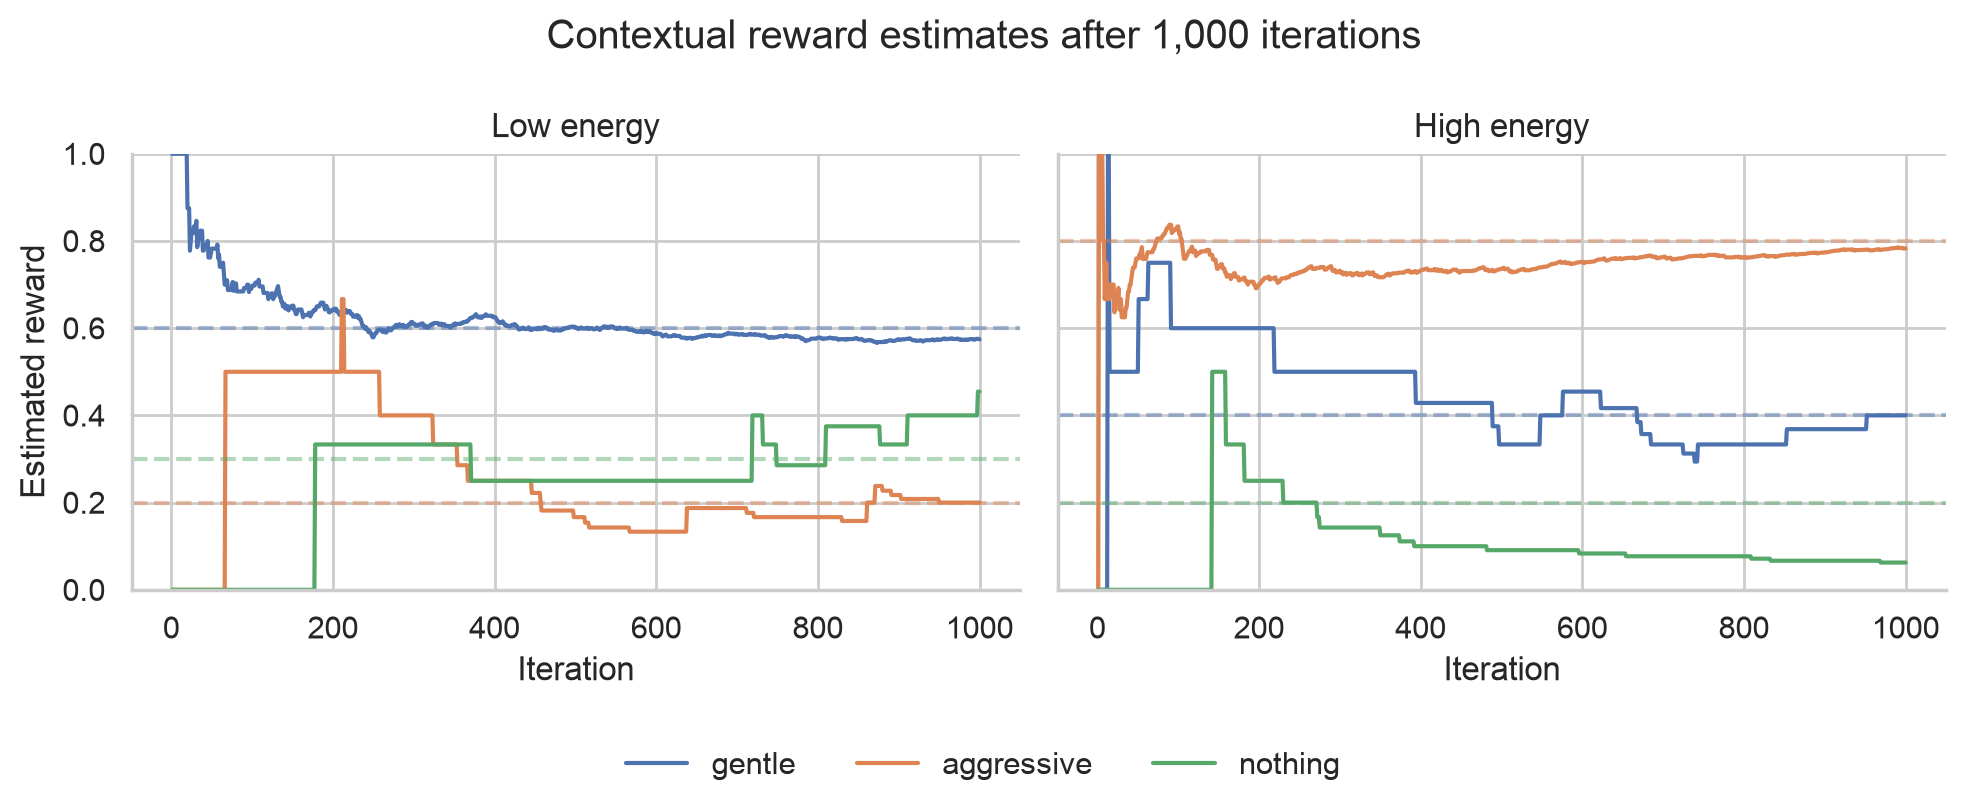

In [3]:
actions = ["gentle", "aggressive", "nothing"]
n_actions = len(actions)

contexts = ["low", "high"]
reward_probs = {
    "low": [0.6, 0.2, 0.3],
    "high": [0.4, 0.8, 0.2],
}
counts = {ctx: [0] * n_actions for ctx in contexts}
values = {ctx: [0.0] * n_actions for ctx in contexts}
estimate_history = []

n_iters = 1000
for step in range(n_iters):
    step_context = get_context(contexts)
    _, action = choose_action(n_actions, values, step_context, epsilon=0.1)
    reward = environment(reward_probs, step_context, action)
    update(counts, values, step_context, action, reward)
    estimate_history.append({context: estimates.copy() for context, estimates in values.items()})

print("Counts:", counts)
print("True rewards:", reward_probs)
print("Estimated rewards:", pprint(values, actions))

plot_progress(estimate_history, reward_probs, actions)